# Libraries and loading data

In [33]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import pickle
import os
from matplotlib.pyplot import figure
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
Colors = sns.color_palette("colorblind", 16).as_hex()
import matplotlib.pyplot as plt
text_size=26
fig_size_x=24
fig_size_y=14
from scipy.interpolate import interp1d
import pandas as pd
import ast
import time
from collections import defaultdict
import time
from colossus.lss import peaks
from colossus.lss import bias
from colossus.cosmology import cosmology
cosmology.setCosmology('planck18');
import MAS_library as MASL
import plotting_library as PL
from pylab import *
from matplotlib.colors import LogNorm
import matplotlib as plt
import pandas as pd
import h5py as h5
import matplotlib.pyplot as plt
from colossus.cosmology import cosmology
from colossus.lss import mass_function
import mass_function_library as MFL
import readgadget
import Pk_library as PKL

In [34]:
aa = np.loadtxt("/mn/stornext/u3/hassanif/neutrino_niayesh/simulations/L_1024_Ngrid_512/0.0ev/output/halos/subhalo_out_2.list")

In [35]:
np.shape(aa[aa[:,41]==-1][:,41])[0]/np.shape(aa[:,41])[0]

4.904870045468146e-06

In [37]:
aa[aa[:,41]==-1][:,41]

array([-1.])

# Loading CLASS spectra

In [2]:
###
def nested_dict(n, type):
    if n == 1:
        return defaultdict(type)
    else:
        return defaultdict(lambda: nested_dict(n-1, type))
data = nested_dict(6, list)

sims = ["0d0", "0d15", "0d3", "0d6"]
redshifts = [100, 50, 30,20, 10, 9, 8, 7, 6 , 5, 4, 3, 2.5, 2, 1.5, 1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0.05, 0.01, 0]
for sim in sims:
    for z in redshifts:
        data['tk'][z] = np.loadtxt("./../../runs_class/output/"+sim+"_z"+str(redshifts.index(0)+1)+"_tk.dat")
        data['pk_lin'][z] = np.loadtxt("./../../runs_class/output/"+sim+"_z"+str(redshifts.index(0)+1)+"_pk.dat")
        data['pk_nl'][z] = np.loadtxt("./../../runs_class/output/"+sim+"_z"+str(redshifts.index(0)+1)+"_pk_nl.dat")


## Simulation data load

In [3]:
### cdm
snapshot ='/mn/stornext/d14/gravity/personal/hassanif/projects/Neutrino_Niayesh//simulations/L_1024_Ngrid_512/0.6ev/output/snap002_cdm'
ptype = [1]
pos_cdm = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
vel_cdm = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s
### neutrinos
snapshot ='/mn/stornext/d14/gravity/personal/hassanif/projects/Neutrino_Niayesh//simulations/L_1024_Ngrid_512/0.6ev/output/snap002_ncdm0'
ptype = [1]
pos_nu = readgadget.read_block(snapshot, "POS ", ptype)/1e3 #positions in Mpc/h
vel_nu = readgadget.read_block(snapshot, "VEL ", ptype)     #peculiar velocities in km/s

# Computing power spectra

In [4]:
# parameters
snapshot      = '/mn/stornext/d14/gravity/personal/hassanif/projects/Neutrino_Niayesh//simulations/L_1024_Ngrid_512/0.6ev/output/snap002_cdm'
grid          = 512    #grid size
particle_type = [1]    #use dark matter [1]
cpus          = 8      #number of openmp threads
folder_out    = './' #folder where to write results
do_RSD        = False   #move particles to redshift-space and calculate Pk in redshift-space
axis = 0
# compute power spectrum of the snapshot
PKL.Pk_Gadget(snapshot, grid, particle_type, do_RSD, axis, cpus, folder_out)

Computing power spectrum...
0.000 < X [Mpc/h] < 1024.000
0.000 < Y [Mpc/h] < 1024.000
0.000 < Z [Mpc/h] < 1024.000


Computing power spectrum of the field...
Time to complete loop = 8.13
Time taken = 8.78 seconds


## Neutrino power

In [5]:
# parameters
snapshot      = '/mn/stornext/d14/gravity/personal/hassanif/projects/Neutrino_Niayesh//simulations/L_1024_Ngrid_512/0.6ev/output/snap002_ncdm0'
grid          = 512    #grid size
particle_type = [1]    #use dark matter [1]
cpus          = 8      #number of openmp threads
folder_out    = './' #folder where to write results
do_RSD        = False   #move particles to redshift-space and calculate Pk in redshift-space
axis = 0
# compute power spectrum of the snapshot
PKL.Pk_Gadget(snapshot, grid, particle_type, do_RSD, axis, cpus, folder_out)

Computing power spectrum...
0.000 < X [Mpc/h] < 1024.000
0.000 < Y [Mpc/h] < 1024.000
0.000 < Z [Mpc/h] < 1024.000


Computing power spectrum of the field...
Time to complete loop = 8.13
Time taken = 8.82 seconds


# Velocity Power

### CDM

In [37]:
# # parameters
# BoxSize = 1024.0 #Mpc/h
# axis    = 0      #velocity fields in real-space; this variable is not relevant in real-space
# MAS     = 'CIC'  #mass-assignment scheme used to create the velocity field
# threads = 20     #number of openmp threads to be used

# ### Velocity fields
# # define the array hosting the velocity fields
# Vx = np.zeros((grid,grid,grid), dtype=np.float32)
# Vy = np.zeros((grid,grid,grid), dtype=np.float32)
# Vz = np.zeros((grid,grid,grid), dtype=np.float32)

# # compute the theta auto-power spectrum
# Vx = vel_cdm[:,0]
# Vy = vel_cdm[:,1]
# Vz = vel_cdm[:,2]
# k, Pk, Nmodes = PKL.Pk_theta(Vx,Vy,Vz, BoxSize,axis,MAS,threads)

# # k will be in h/Mpc units. Pk will have (km/s)^2*(Mpc/h)^3 considering that the velocity field is in km/s

### nu

# Power spectra comparisons

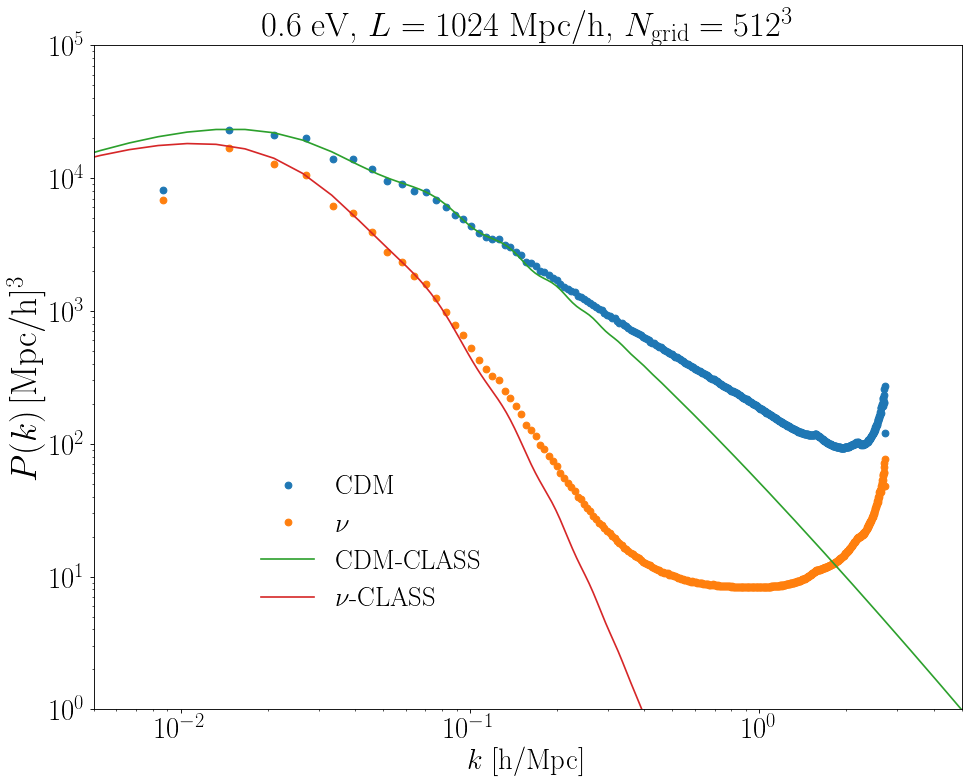

In [63]:

###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)

pk_cdm = np.loadtxt("./Pk_cdm_z=0.000.dat")
pk_nu = np.loadtxt("./Pk_nu_z=0.000.dat")


plt.loglog(pk_cdm[:,0],pk_cdm[:,1],"o", label =r"CDM")
plt.loglog(pk_nu[:,0],pk_nu[:,1],"o", label =r"$\nu$")

z=0
tk = data['tk'][z];
As = 2.215e-9
kp = 0.05;
ns = 0.9619
k = tk[:,0]
coeff = As* (k/kp)**(ns-1);
pk = coeff * (tk[:,3]**2)*(2.*np.pi**2)/k**3
plt.loglog(k,pk,"-", label =r"CDM-CLASS")

####
z=0
tk = data['tk'][z];
As = 2.215e-9
kp = 0.05;
ns = 0.9619
k = tk[:,0]
coeff = As* (k/kp)**(ns-1);
pk = coeff * (tk[:,4]**2)*(2.*np.pi**2)/k**3
plt.loglog(k,pk,"-", label =r"$\nu$-CLASS")


plt.xlim(0.005,5)
plt.title(r"0.6 eV, $L = 1024$ Mpc/h, $N_{\rm grid} = 512^3 $")
plt.ylim(1,1.e5)
plt.xlabel(r"$k$ [h/Mpc]")
plt.ylabel(r'$P(k) \,[{\rm{Mpc}/h}]^3$',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=24,bbox_to_anchor=[0.32,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# Velocity spectra comparison

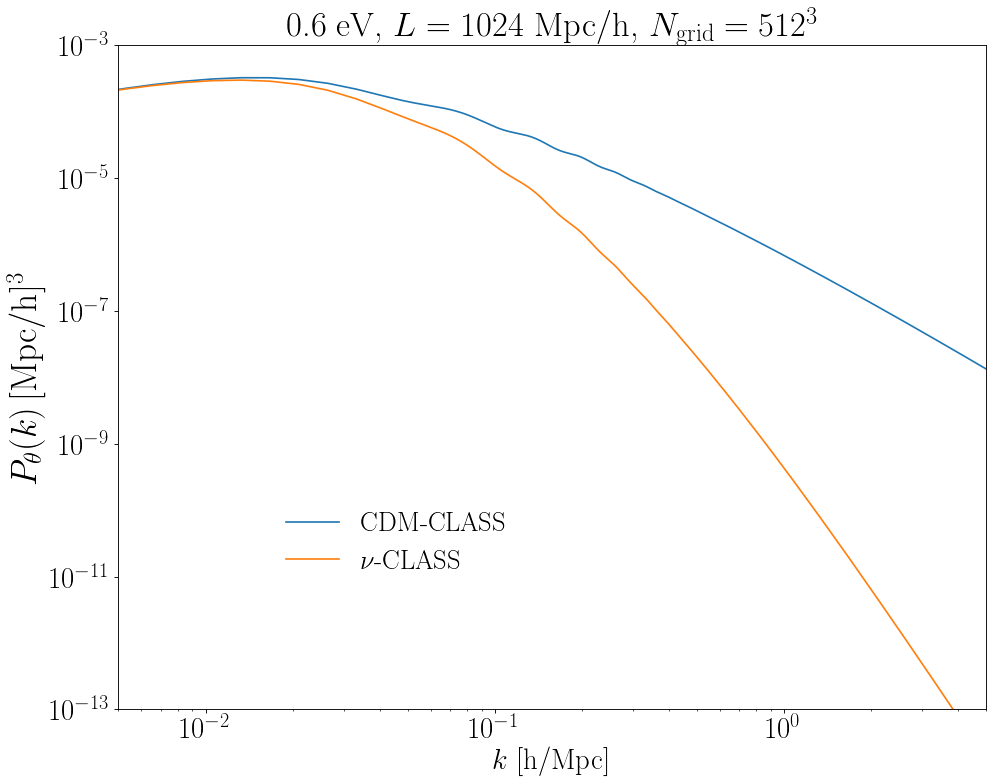

In [64]:

###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)

# pk_cdm = np.loadtxt("./Pk_cdm_z=0.000.dat")
# pk_nu = np.loadtxt("./Pk_nu_z=0.000.dat")


# plt.loglog(pk_cdm[:,0],pk_cdm[:,1],"o", label =r"CDM")
# plt.loglog(pk_nu[:,0],pk_nu[:,1],"o", label =r"$\nu$")

z=0
tk = data['tk'][z];
As = 2.215e-9
kp = 0.05;
ns = 0.9619
k = tk[:,0]
coeff = As* (k/kp)**(ns-1);
pk = coeff * (tk[:,10]**2)*(2.*np.pi**2)/k**3
plt.loglog(k,pk,"-", label =r"CDM-CLASS")

####
z=0
tk = data['tk'][z];
As = 2.215e-9
kp = 0.05;
ns = 0.9619
k = tk[:,0]
coeff = As* (k/kp)**(ns-1);
pk = coeff * (tk[:,11]**2)*(2.*np.pi**2)/k**3
plt.loglog(k,pk,"-", label =r"$\nu$-CLASS")


plt.xlim(0.005,5)
plt.title(r"0.6 eV, $L = 1024$ Mpc/h, $N_{\rm grid} = 512^3 $")
plt.ylim(1.e-13,1.e-3)
plt.xlabel(r"$k$ [h/Mpc]")
plt.ylabel(r'$P_{\theta}(k) \,[{\rm{Mpc}/h}]^3$',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=24,bbox_to_anchor=[0.32,0.25],loc="center",frameon=False)# plt.yscale('symlog')

## Print the headers and each column

In [7]:
f = open("./../../simulations/"+sim_spec_s+sim+"/output/halos/out_2.list")
g = open("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat")

header = f.readline()
header_l = g.readline()

header_list = header.split(' ') #list of columns
header_list_l = header_l.split(' ') #list of columns

print(header_list)
print(header_list_l)
print(header_list.index("Mvir"))
for num in [0, 1, 2, 20]:
    print("Column: "+str(num)+ " is " + header_list[num])


['#ID', 'DescID', 'Mvir', 'Vmax', 'Vrms', 'Rvir', 'Rs', 'Np', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ', 'JX', 'JY', 'JZ', 'Spin', 'rs_klypin', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'spin_bullock', 'b_to_a', 'c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)', 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|', 'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius\n']
['#ID', 'DescID', 'Mvir', 'Vmax', 'Vrms', 'Rvir', 'Rs', 'Np', 'X', 'Y', 'Z', 'VX', 'VY', 'VZ', 'JX', 'JY', 'JZ', 'Spin', 'rs_klypin', 'Mvir_all', 'M200b', 'M200c', 'M500c', 'M2500c', 'Xoff', 'Voff', 'spin_bullock', 'b_to_a', 'c_to_a', 'A[x]', 'A[y]', 'A[z]', 'b_to_a(500c)', 'c_to_a(500c)', 'A[x](500c)', 'A[y](500c)', 'A[z](500c)', 'T/|U|', 'M_pe_Behroozi', 'M_pe_Diemer', 'Halfmass_Radius', 'PID\n']
2
Column: 0 is #ID
Column: 1 is DescID
Column: 2 is Mvir
Column: 20 is M200b


# Different force resolution small sim

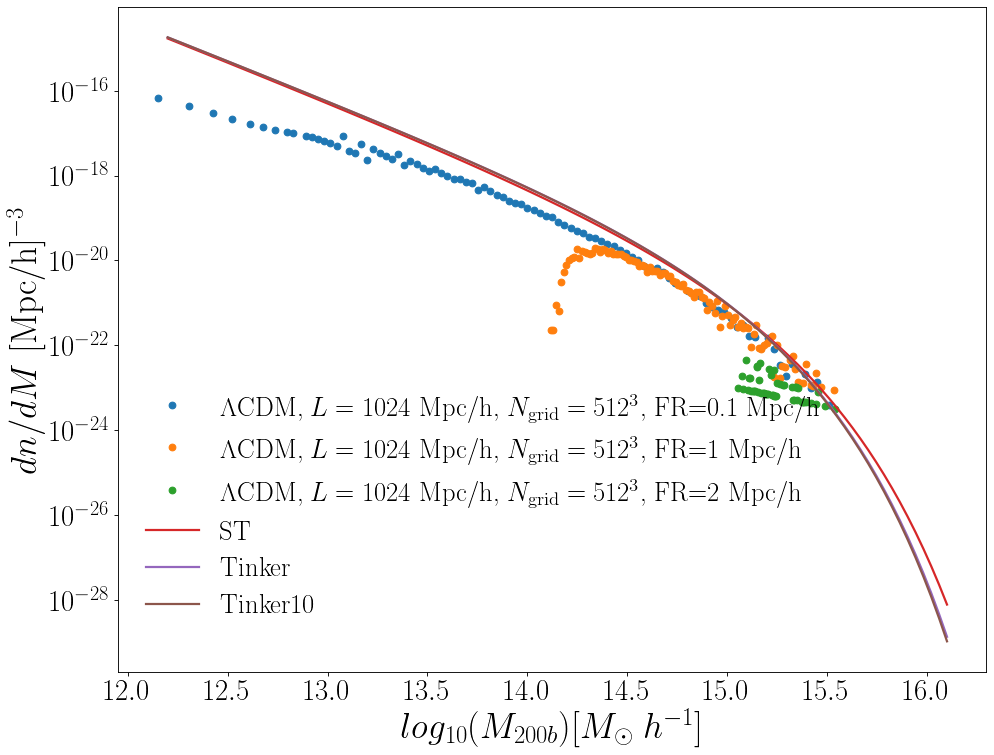

In [12]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=0.1 Mpc/h")


nbins = 110;
boxsize = 1024
x=halos_catalogue_small_force1[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=1 Mpc/h")


nbins = 110;
boxsize = 2048
x=halos_catalogue_small_force2[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$, FR=2 Mpc/h")

for author in names:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=24,bbox_to_anchor=[0.42,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Different force resolution medium sim

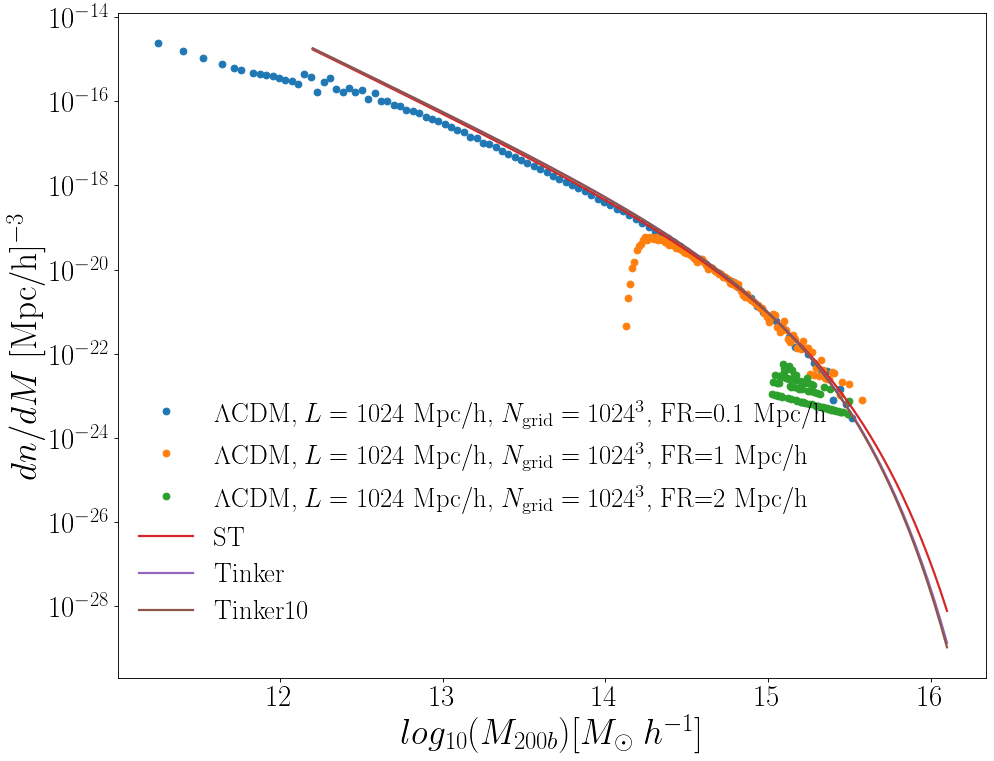

In [14]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$, FR=0.1 Mpc/h")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium_force1[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$, FR=1 Mpc/h")


nbins = 110;
boxsize = 2048
x=halos_catalogue_medium_force2[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$, FR=2 Mpc/h")

for author in names:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=24,bbox_to_anchor=[0.42,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# Plotting halo mass function

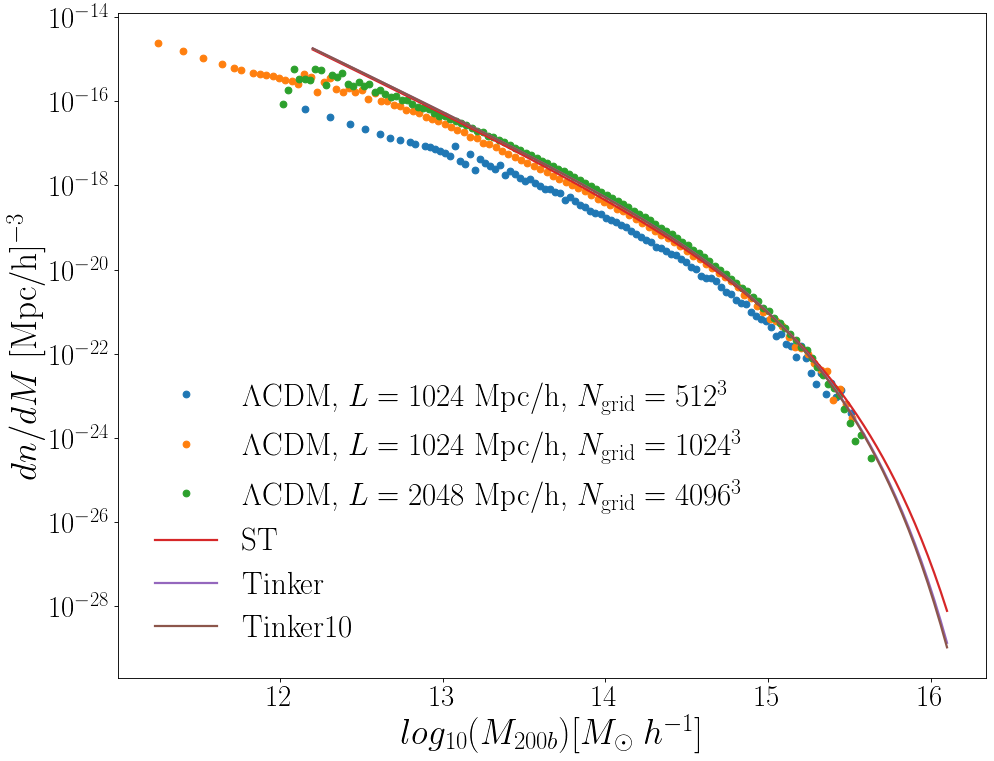

In [7]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096^3$")

for author in names:
    plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

# $M_{\rm vir}$

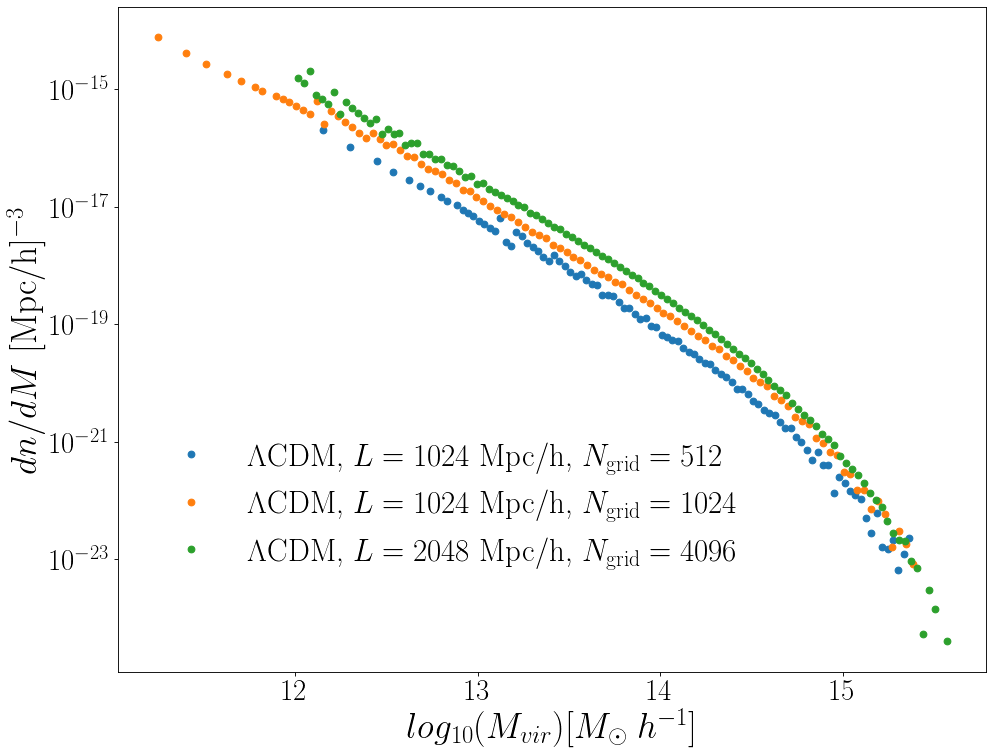

In [6]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,2];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096$")



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{vir}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

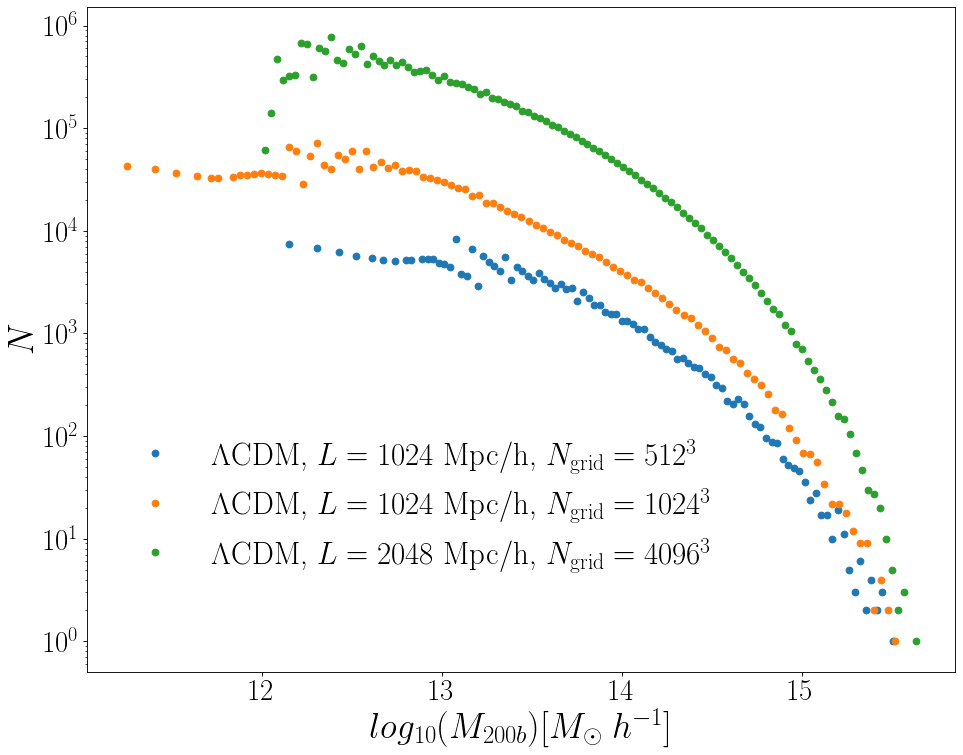

In [11]:
## Halo model:
model = 'sheth01'
z = 0.0
mdef = '200m'
###FIG###
c=26
plt.rc('text', usetex=True)
font = {'family' : 'normal',
        'weight' : 'bold',
        'size'   : c}
matplotlib.rc('font', **font)
figure(figsize=(14, 11), dpi=80)
sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
sims_large = ["0meV", "200meV", "300meV", "60meV"]

nbins = 110;
boxsize = 1024
x=halos_catalogue_small[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 512^3$")


nbins = 110;
boxsize = 1024
x=halos_catalogue_medium[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=1024$ Mpc/h, $N_{\rm grid} = 1024^3$")


nbins = 110;
boxsize = 2048
x=halos_catalogue_large[:,20];
counts = np.histogram(np.log10(x), bins=nbins)[0]
bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
deltaM= bin_edges[2]- bin_edges[1];
plt.semilogy(bin_edges[:-1],counts,"o", label =r"$\Lambda$CDM, $L=2048$ Mpc/h, $N_{\rm grid} = 4096^3$")

# for author in names:
#     plt.plot(log10(Masses), HMF[author]['dNdlogM']['lcdm'],lw=2,label=author) 



plt.xlabel(r"$dx$ [Mpc/h]")
plt.ylabel(r'$N$',fontsize=32)
plt.xlabel(r'$log_{10} (M_{200 b}) [ M_{\odot} \; h^{-1}$]',fontsize=32)
plt.yscale('log')
plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )

## 0.3 eV

In [54]:
# sim_spec_s= "L_1024_Ngrid_512/"
# sim_spec_m= "L_1024_Ngrid_1024/"
# sim="0.3ev"
# sim_l="nu300meV"

# halos_catalogue_small = np.loadtxt("./../../simulations/"+sim_spec_s+sim+"/output/halos/out_2.list");
# halos_catalogue_medium =np.loadtxt("./../../simulations/"+sim_spec_m+"/simulations/"+sim+"/output/halos/out_2.list");
# halos_catalogue_large = np.loadtxt("./../../simulations/Neutrino_runs_JulianAdamek/"+sim_l+"_2048box_4096_snap004_halos_parents.dat");


In [8]:
# ## Halo model:
# model = 'sheth01'
# z = 0.0
# mdef = '200m'
# ###FIG###
# c=26
# plt.rc('text', usetex=True)
# font = {'family' : 'normal',
#         'weight' : 'bold',
#         'size'   : c}
# matplotlib.rc('font', **font)
# figure(figsize=(14, 11), dpi=80)
# sims = ['0.0ev', '0.15ev', '0.3ev', '0.6ev']
# sims_large = ["0meV", "200meV", "300meV", "60meV"]

# nbins = 110;
# boxsize = 1024
# x=halos_catalogue_small[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=1024$ Mpc/h, $N_{\rm grid} = 512$")


# nbins = 110;
# boxsize = 1024
# x=halos_catalogue_medium[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=1024$ Mpc/h, $N_{\rm grid} = 1024$")


# nbins = 110;
# boxsize = 2048
# x=halos_catalogue_large[:,20];
# counts = np.histogram(np.log10(x), bins=nbins)[0]
# bin_edges = np.histogram(np.log10(x), bins=nbins)[1]
# deltaM= bin_edges[2]- bin_edges[1];
# plt.semilogy(bin_edges[:-1],counts/((10**(roll(bin_edges[:],-1)) -10**bin_edges[:])[:-1])/boxsize**3,"o", label =r"$\sum M_{\nu}$=0.3 eV, $L=2048$ Mpc/h, $N_{\rm grid} = 4096$")



# plt.xlabel(r"$dx$ [Mpc/h]")
# plt.ylabel(r'$dn/dM$ [Mpc/h]$^{-3}$',fontsize=32)
# plt.xlabel(r'$log_{10} M[ M_{\odot} \; h^{-1}$]',fontsize=32)
# plt.yscale('log')
# plt.legend(fontsize=28,bbox_to_anchor=[0.38,0.25],loc="center",frameon=False)# plt.yscale('symlog')

# # plt.savefig(sim+".jpeg", format='pdf',dpi=300, bbox_inches='tight' )